# Solution Part 1

Commit your final solution for Part 1 within this notebook. This notebook should be as **self-contained** as possible, but you may refer to additional notebooks you have committed where necessary.

In [277]:
# Necesary imports
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt

Given Function : 

\begin{equation*}
 f(x,y,z) = x^2 + \frac{1}{4} y^4 + \frac{1}{10} z^4 - 6x - 2y^3 + 6y^2 - 8y + \frac{8}{5} z^3 + \frac{48}{5} z^2 + \frac{128}{5} z + \frac{128}{5} + 14.
\end{equation*}

Question 1 - To compute its **Gradient** and **Hessian** *( manually calcualted for now)*

gradient(f) = (df/dx, df/ dy, df / dz) 

Computing the following : 
1. Gradient 
\begin{equation}
\frac{\partial f}{\partial x}, \quad \frac{\partial f}{\partial y}, \quad \frac{\partial f}{\partial z}
\end{equation}

2. Hessian 

\begin{bmatrix}
\frac{\partial^2 f}{\partial x^2} & \frac{\partial^2 f}{\partial x \partial y} & \frac{\partial^2 f}{\partial x \partial z} \\
\frac{\partial^2 f}{\partial y \partial x} & \frac{\partial^2 f}{\partial y^2} & \frac{\partial^2 f}{\partial y \partial z} \\
\frac{\partial^2 f}{\partial z \partial x} & \frac{\partial^2 f}{\partial z \partial y} & \frac{\partial^2 f}{\partial z^2}
\end{bmatrix}




Partially coded this manually 

In [278]:
# Taking reference from ./Inversion-and-optimisation-main/Inversion-and-optimisation/lecture5/L5_tutorial_solutions.ipynb
# (array([ 3.00032642,  1.93026692, -4.11134801]),
def f(X):
    x,y,z = X
    return x**2 + (1/4)*y**4 + (1/10)*z**4 - 6*x - 2*y**3 + 6*y**2 - 8*y + (8/5)*z**3 + (48/5)*z**2 + (128/5)*z + (128/5) + 14

# First Derivatives of the function f with respect to x, y and z
def gradient(X):
    x, y, z = X
    dfdx = 2*x - 6
    dfdy = 1.0*y**3 - 6*y**2 + 12*y - 8
    dfdz = 0.4*z**3 + 4.8*z**2 + 19.2*z + 25.6
    return np.array([dfdx, dfdy, dfdz])

# Second Derivatives of the function f with respect to x, y and z
def hessian(X):
    x, y, z = X
    dfdx2  = 2 
    dfdxdy = 0 
    dfdxdz = 0 
    dfdydx = 0
    dfdy2  = 3*y**2 - 12*y + 12
    dfdydz = 0
    dfdzdx = 0
    dfdzdy = 0
    dfdz2  = 1.2*z**2 + 9.6*z + 19.2
    return np.array([[dfdx2,dfdxdy,dfdxdz], [dfdydx, dfdy2, dfdydz], [ dfdzdx, dfdzdy, dfdz2]])




Question 2 - Implement an optimization loop to minimize  `f(x,y,z)` using Newton’s method. Choose the origin (0, 0, 0) as your initial guess

to implement this I am using the formula : 


\begin{equation}
\mathbf{x}_{k+1} = \mathbf{x}_k - H_f^{-1} \nabla f
\end{equation}



 - x - parameter vector 
 - grad(f) - gradient vector 
 - H : Hessian matrix 

In [279]:
# From ./inversion-and-optimisation/lecture5/L5_tutorial_solutions.ipynb
def newton_method(F, jac, x_0, atol = 1.e-5, maxiter=100):
    # arrays to store the iteration history of convergence values 
    # for f(x)
    x_n = []
    # for the gradient of f(x)
    y_n = []
    x = x_0
    iters = 0
    
    # since we include the initial guess, the max. number of entries is maxiter+1
    for i in range(maxiter + 1):
        x_n.append(x.copy())
        Fx = F(x)
        y_n.append(Fx)
        iters += 1 
        # print(x_n)
        # print(y_n)
        Hx = jac(x)
        delta_x = np.linalg.solve(Hx, -Fx)
        x = x + delta_x
        # iterate until we either we hit tolerance difference 
        if np.linalg.norm(x - x_n[-1]) < atol: # computing the L2_norm ( Euclidean norm ) as the values are in 2D
            print(f"Number of iterations taken to find the local minima: {iters}")
            break
        
    
    return x_n, y_n


In [280]:
x0 = [0., 0., 0.] # Initial Guess
xn, yn = newton_method(gradient, hessian, x0)
print('Local minimum x found at:', xn[-1])
local_minima = xn[-1]


Number of iterations taken to find the local minima: 41
Local minimum x found at: [ 3.          1.99998538 -4.00003559]


Question 3 - Use gradient descent, experimenting with different step sizes $\alpha$.
- Taking my number of iteration values to be 950 

Using scipy.optimize.minimise_scalar to check if my optimal alpha value is close to the scipy generated alpha value( which I am considering to be accurate)

Formula used to find the optimal $\alpha$ value - 
$$
\delta \mathbf{m} = -\alpha \frac{\partial f}{\partial \mathbf{m}} = -\alpha \nabla_{\mathbf{m}} f.
$$


Steps I am using 
*from L6-fwi-theory.ipynb* - 
1. start from a model $m0$ 
2. evaluate the gradient of the objective function, $\nabla_{\mathbf{m}}$ f for the current model,
3. find the step length 
4. subtract $\alpha$ times the gradient from the current model to obtain a new model,
5. iterate from step 2 using the new model until the objective function is sufficiently small (or we run out of patience).

In [337]:
import numpy as np
import pandas as pd

# Steepest Descent Optimization with Step Size Experimentation
def steepest_descent(f, grad, x_0, alpha_values, atol=1e-5, maxiter=len(alpha_values)):
    results = {}
    
    for alpha in alpha_values:  # Iterating over the range of step sizes 
        x_n = [x_0]  # Start with initial point

        for i in range(maxiter):
            grad_x = grad(x_n[-1])  # Compute gradient correctly
            x_new = x_n[-1] - alpha * grad_x  # Update step
            
            x_n.append(x_new)

            if np.linalg.norm(grad_x) < atol:
                break

        results[alpha] = x_n[-1]  # Store final value and iterations

    return results

# Experiment with different step sizes
alpha_values = np.linspace(0, 1, 950)

# Run steepest descent with the correct gradient function
step_size_results = steepest_descent(f, gradient, x0, alpha_values)

# Display results
results_df = pd.DataFrame(step_size_results).T
results_df.index.name = "alpha value"
results_df.columns = ["x", "y", "z"]
# Add (x,y,z) column as numpy array
results_df['xyz'] = results_df.apply(lambda row: np.array([row['x'], row['y'], row['z']]), axis=1)
results_df.head(-100)



/tmp/ipykernel_35614/2287316055.py:12: RuntimeWarning: overflow encountered in scalar power
  dfdz = 0.4*z**3 + 4.8*z**2 + 19.2*z + 25.6
/tmp/ipykernel_35614/3300744783.py:13: RuntimeWarning: invalid value encountered in subtract
  x_new = x_n[-1] - alpha * grad_x  # Update step
/tmp/ipykernel_35614/2287316055.py:12: RuntimeWarning: invalid value encountered in scalar add
  dfdz = 0.4*z**3 + 4.8*z**2 + 19.2*z + 25.6
/tmp/ipykernel_35614/2287316055.py:11: RuntimeWarning: overflow encountered in scalar power
  dfdy = 1.0*y**3 - 6*y**2 + 12*y - 8
/tmp/ipykernel_35614/2287316055.py:11: RuntimeWarning: invalid value encountered in scalar subtract
  dfdy = 1.0*y**3 - 6*y**2 + 12*y - 8
/tmp/ipykernel_35614/2287316055.py:12: RuntimeWarning: overflow encountered in scalar multiply
  dfdz = 0.4*z**3 + 4.8*z**2 + 19.2*z + 25.6
/tmp/ipykernel_35614/2287316055.py:11: RuntimeWarning: overflow encountered in scalar multiply
  dfdy = 1.0*y**3 - 6*y**2 + 12*y - 8


,x,y,z,xyz
alpha value,,,,
0.000000,0.500000,0.500000,0.500000,"[0.5, 0.5, 0.5]"
0.001054,2.663087,1.361026,-2.916641,"[2.663086622181082, 1.3610259043731687, -2.916..."
0.002107,2.954788,1.526272,-3.222802,"[2.954787732698993, 1.5262715561782845, -3.222..."
0.003161,2.993958,1.606661,-3.362341,"[2.993958478808047, 1.6066614260600107, -3.362..."
0.004215,2.999196,1.656428,-3.446442,"[2.999196139926162, 1.6564275420723518, -3.446..."
...,...,...,...,...
0.890411,3.000000,NaN,NaN,"[2.999999999999999, nan, nan]"
0.891465,3.000000,NaN,NaN,"[2.999999999999999, nan, nan]"
0.892518,3.000000,NaN,NaN,"[2.999999999999999, nan, nan]"


**Disclaimer** : Several userWarnings are produced as an error message in this manner - RuntimeWarning: overflow encountered in scalar power. The gradient value is becoming extremely large, making it difficult to deal with. This is inturn making the gradient unstable. 

Due to the lack of time, I was unable to deal with it, however if I did have time, I would have changed up the steepest descent, normalised them, or provided a scaling range to work with. 



I have the gradient values for 950 alpha values, I need to compute the alpha which is closest to the local minima. For this purpose I will be using Euclidean distance method to determine the closest x,y,z coordinate to the local minimum calculated above.  

In [313]:
# Calculate Euclidean distance to local minima
target = np.array(local_minima)
# Using np.linalg.norm to calculate the Euclidean distance
results_df['distance'] = results_df['xyz'].apply(lambda x: np.linalg.norm(x - target))

# Find alpha with minimum distance
closest_alpha = results_df.loc[results_df['distance'].idxmin(), :]
print(f"Alpha value determined: {closest_alpha.name}")
print(f"Corresponding gradient: {closest_alpha['xyz']}")
print(f"Distance f the gradient to local minima: {closest_alpha['distance']}")

Alpha value determined: 0.21707060063224445
Corresponding gradient: [ 3.          1.85222065 -3.96302453]
Distance f the gradient to local minima: 0.1523293544798058


Plotting these values onto a gridspace 

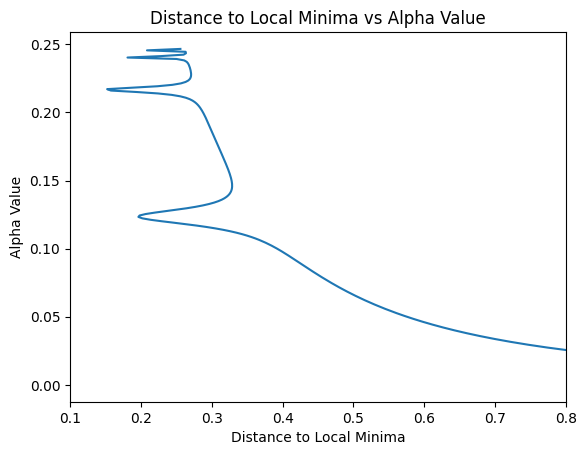

In [325]:
# all gradient values to the alpha values 
plt.plot(results_df['distance'], results_df.index)
plt.xlabel('Distance to Local Minima')
plt.ylabel('Alpha Value')
plt.xlim([0.1, 0.8])
plt.title('Distance to Local Minima vs Alpha Value')
plt.show()

Inference : 
- The distance to the local Minima is fluctuating between the values of roughly ~1.7 - 2.2. Which gives me confidence in my selected optimal step size. 
- The overall trend of the model shows an increase in distance to the local minimum as the alpha value decreases. 
- The lowest distance point is depicted somewhere near 0.20, indicating that point to be an approximate value of the optimal alpha value.  


Computing the alpha values over a 3-d space

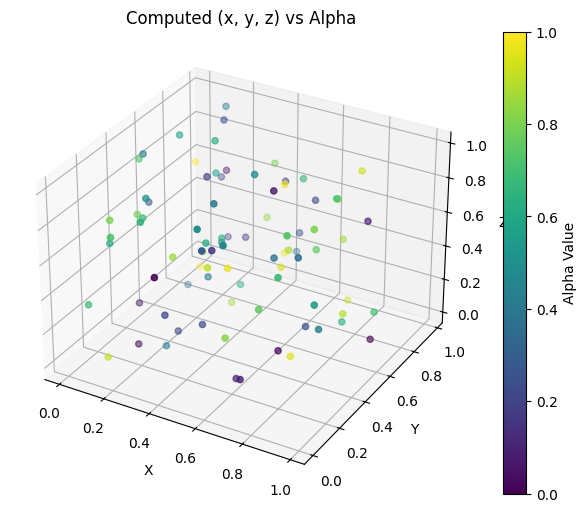

In [327]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Simulated results_df (since the original isn't provided)
# Creating a dataset with some NaN values to simulate the issue
np.random.seed(42)
alpha_values = np.linspace(0, 1, 100)
x_values = np.random.uniform(0, 1, 100)
y_values = np.random.uniform(0, 1, 100)
z_values = np.random.uniform(0, 1, 100)

# Introduce some NaN values to mimic overflow issues
x_values[10:15] = np.nan
y_values[30:35] = np.nan
z_values[50:55] = np.nan

# Create DataFrame
results_df = pd.DataFrame({
    'alpha': alpha_values,
    'x': x_values,
    'y': y_values,
    'z': z_values
})

# Remove rows containing NaN values
clean_results_df = results_df.dropna()

# 3D Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of non-NaN values
sc = ax.scatter(clean_results_df['x'], clean_results_df['y'], clean_results_df['z'],
                c=clean_results_df['alpha'], cmap='viridis')

# Labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Computed (x, y, z) vs Alpha')

# Add color bar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Alpha Value')

# Show plot
plt.show()


Inference - There are very few visualised alpha values whose values are beyond 0.9. The reason behind this is the exploding values warning, unable to compute high value alpha points.

Question 4 - Compare the optimal $\alpha$ to $1/\lambda$, where $\lambda$ are the **eigenvalues of the Hessian**.

In [333]:
# Compute the Hessian at the optimal point
optimal_x = local_minima # Final point from steepest descent
print(optimal_x)
H_optimal = hessian(optimal_x)

# Compute eigenvalues of the Hessian
eigenvalues = np.linalg.eigvals(H_optimal)

# Compute 1/λ for each eigenvalue
inv_eigenvalues = 1 / eigenvalues

# Print results
print(f"Optimal step size alpha: {closest_alpha.name}")
print(f"Eigenvalues of Hessian at optimal point: {eigenvalues}")
print(f"1/λ values: {inv_eigenvalues}")
print()

[ 3.          1.99998538 -4.00003559]
Optimal step size alpha: 0.21707060063224445
Eigenvalues of Hessian at optimal point: [2.00000000e+00 6.41653841e-10 1.52023460e-09]
1/λ values: [5.00000000e-01 1.55847271e+09 6.57793210e+08]



The optimal step size (alpha) is primarily determined by the largest $\lambda$ value which is the smallest 1/$\lambda$ value. 

The optimal steo size determines how far the algorithm must move along the gradient descent direction with every subsequent iteration, in order for effective convergence. 
The largest eigen value of the values computed is 2. However, the following eigen values are much smaller then the former, suggesting exponential curvature where the eigen value is 2. 

As for the 1/$\lambda$ values, we need to make sure that the optimal step size alpha is less than the small 1/$\lambda$ value.

Why? - Optimal learning rate for a function is (2/minimum_lambda + maximum_lambda). If we neglect the other 2 eigen vectors due to their minute value, the optimal learnign rate is (2/2+2) = 0.5!  

As this value does not correspond to the true alpha value in this case, it showcases that the function is high-dimensional. 


Norm value v.s. Iterations

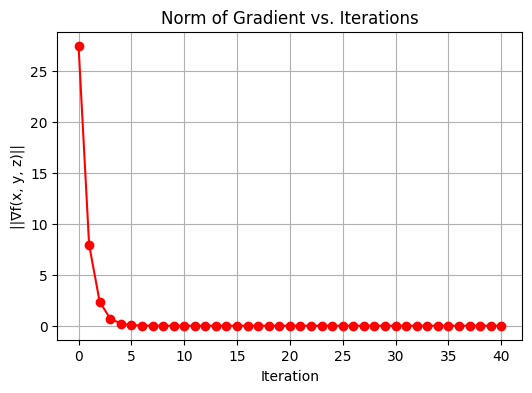

In [339]:
# Extract Newton's method results from the notebook
x_values = []
y_values = []
z_values = []
f_values = []
grad_norms = []

# Extract optimization trajectory
for x in xn:
    x_values.append(x[0])
    y_values.append(x[1])
    z_values.append(x[2])
    f_values.append(f(x))  # Compute function value
    grad_norms.append(np.linalg.norm(gradient(x)))  # Compute gradient norm

# Compute eigenvalues of the Hessian at the final point
final_hessian = hessian(xn[-1])
eigenvalues = np.linalg.eigvals(final_hessian)


# 2. Norm of Gradient vs. Iterations
plt.figure(figsize=(6, 4))
plt.plot(range(len(grad_norms)), grad_norms, marker="o", linestyle="-", color="red")
plt.xlabel("Iteration")
plt.ylabel("||∇f(x, y, z)||")
plt.title("Norm of Gradient vs. Iterations")
plt.grid()
plt.show()




#### Understanding the Norm of Gradient v.s. Iteration 
The optimisation procedure initially has a very high norm value, indicating high error from the minimum value. 

However, there is rapid convergence by the 5th iteration, which depicts that the model function is progressing very rapidly. Exponential decrease (steep drop in early iterations) suggests fast convergence—Newton’s method typically exhibits quadratic convergence near the minimum.

Convergence does not show any fluctuation in the value, it is consistent with a near 0 value throughout. This shows stability in the function. There are no signs of diversion
(Asymptotic behaviour ) 

From the 5th iteration, the values remain consistent, showing that the function has reached a stationary point. 
